## About
this way the autoencoder works somehow but the shape it learned is poor quality and it just does not fit even though it finds outliers similarly to linear model or ML algorithms

In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

In [12]:
from anomaly_detection.utils.plotting_styles import apply_global_style

In [156]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

#dataset = load_dataset("FJ")
dataset = load_dataset("SI")
#dataset += load_dataset("PA")

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\SI\SI01U1\SI01U1_ch


In [ ]:
def resize_histograms(histogram :torch.Tensor, target_bins: int) -> torch.Tensor:
    """
    Resample histograms to a fixed number of bins.

    Args:
        histograms: Tensor shape (batch_size, bins)
        target_bins: desired number of bins

    Returns:
        Tensor shape (batch_size, target_bins)
    """
    if not isinstance(histogram, torch.Tensor):
        histogram = torch.tensor(histogram)

    x = histogram.resize(1,1,histogram.shape[-1])

    x = F.interpolate(
        x,
        size=target_bins,
        mode="linear",
        align_corners=False
    )

    x = x.squeeze(1)

    x = x / (x.sum(dim=1, keepdim=True) + 1e-8)

    return x.squeeze()

In [ ]:
fi_data = minmax_scale_per_sample(drop_empty_histograms(load_dataset("FJ")))
fi_data = torch.stack([resize_histograms(hist, target_bins=1280) for hist in fi_data])

In [ ]:
max_len_in_data = 1280
dataset = torch.stack([resize_histograms(hist, target_bins=max_len_in_data) for hist in dataset])
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)
dataset_no_outs = drop_empty_histograms(full_dataset)

Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546, 808, 1166, 1251, 1428, 1786]


C:\Users\hrdyj\AppData\Local\Temp\ipykernel_2668\3445151194.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  full_dataset = np.array(dataset)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [155]:
encoder = nn.Sequential(
        nn.Conv1d(1, 16, kernel_size=4, stride=2),
        nn.BatchNorm1d(16),
        nn.ReLU(),
        
        nn.Conv1d(16, 32, kernel_size=4, stride=2), # 640
        nn.BatchNorm1d(32),
        nn.ReLU(),

        nn.Conv1d(32, 64, kernel_size=4, stride=2, padding=2), # 320
        nn.BatchNorm1d(64),
        nn.ReLU(),
        )

        # Decoder
decoder = nn.Sequential(
        nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2),
        nn.BatchNorm1d(32),
        nn.ReLU(),

        nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2),
        nn.BatchNorm1d(16),
        nn.ReLU(),

        nn.ConvTranspose1d(16, 1, kernel_size=4, stride=2),
        nn.BatchNorm1d(1),
        nn.ReLU(),) 


pt = X_train[0].reshape(1,1,1280)
pt = torch.tensor(pt)
decoder(encoder(pt)).shape

torch.Size([1, 1, 1294])

In [51]:
from torch.utils.data import DataLoader
from anomaly_detection.utils.autoencoders import HistDataset

In [ ]:
class AE1280(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=4, stride=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            
            nn.Conv1d(16, 32, kernel_size=4, stride=2), # 640
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=4, stride=2), # 320
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.ConvTranspose1d(32, 16, kernel_size=4, stride=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.ConvTranspose1d(16, 1, kernel_size=4, stride=2),
            nn.BatchNorm1d(1),
            nn.ReLU(),

            nn.Linear(1278, 1280),
            nn.Sigmoid()) 
            

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
from anomaly_detection.utils.losses import wasserstein_1d_loss
# def wasserstein_1d_loss(p: torch.Tensor, q: torch.Tensor, eps: float = 1e-8):
#     """
#     p, q: shape (batch_size, 96)
#     assumes non-negative values
#     """

#     # normalize to probability distributions
#     p = p / (p.sum(dim=-1, keepdim=True) + eps)
#     q = q / (q.sum(dim=-1, keepdim=True) + eps)

#     # cumulative distribution functions
#     cdf_p = torch.cumsum(p, dim=-1)
#     cdf_q = torch.cumsum(q, dim=-1)

#     # W1 distance
#     loss = torch.mean(torch.abs(cdf_p - cdf_q).sum(dim=-1))
#     return loss

In [126]:
from anomaly_detection.utils.autoencoders import HistDataset

batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ae_conv = AE1280()

criterion = wasserstein_1d_loss
lam = 10e-4
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.0002)

In [127]:
from anomaly_detection.utils.autoencoders import train_ae

ae_conv.train()
train_losses, val_losses, ae_conv = train_ae(n_epochs=100, 
                                             dataloader=train_loader, 
                                             model=ae_conv, 
                                             val_loader=test_loader, 
                                             optimizer=optimizer, 
                                             criterion=criterion,
                                             add_regularization=True,
                                             lam=lam,
                                             save_checkpoints=False,
                                             saving_after_epoch=20,
                                             model_name="ofa_ae_conv_v3.1_Wass_Reg",
                                             input_dim=12,
                                             latent_dim=24)

Ep [0 / 100]: Train loss 48.40799656320125 | test loss 49.72607930501302
Ep [25 / 100]: Train loss 3.9978974852037314 | test loss 4.681946496168773
Ep [50 / 100]: Train loss 2.9837263112982417 | test loss 4.142703632513682
Ep [75 / 100]: Train loss 2.71185825671993 | test loss 4.520714501539866


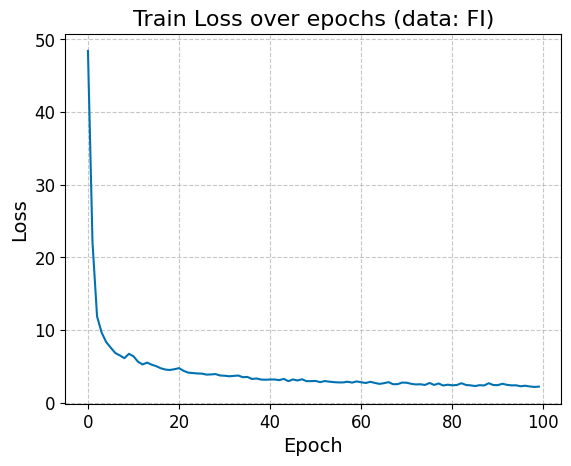

In [128]:
apply_global_style()
plt.title("Train Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses)
plt.show()

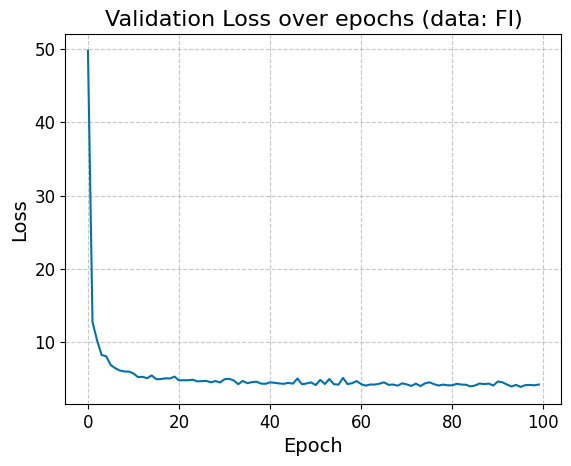

In [129]:
apply_global_style()
plt.title("Validation Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(val_losses)), val_losses)
plt.show()

In [130]:
full_dataset = HistDataset(full_dataset)
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

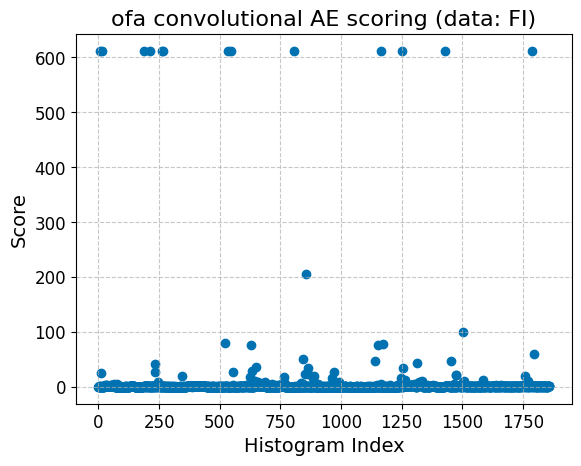

In [131]:
apply_global_style()
plt.title("ofa convolutional AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")

model=ae_conv
model.eval()
score = []

with torch.no_grad():
    for pt in full_dataset:
        pred = ae_conv(pt.reshape(1, 1, pt.shape[-1]))
        loss = criterion(pred, pt).detach().numpy()
        score.append(loss)

plt.scatter(range(len(score)), score)
plt.show()

In [132]:
outliers = np.where(np.array(score) > 5)
outliers

(array([   8,   11,   15,   65,   75,  188,  214,  233,  234,  244,  263,
         268,  344,  520,  533,  546,  555,  626,  628,  631,  635,  645,
         651,  658,  660,  677,  687,  715,  751,  759,  760,  763,  767,
         808,  834,  843,  845,  853,  854,  863,  864,  883,  888,  907,
         964,  965,  973,  993, 1140, 1153, 1165, 1166, 1175, 1248, 1251,
        1255, 1264, 1269, 1300, 1315, 1318, 1319, 1320, 1321, 1322, 1327,
        1333, 1334, 1335, 1336, 1428, 1454, 1465, 1473, 1474, 1502, 1503,
        1505, 1508, 1584, 1760, 1773, 1786, 1795]),)

In [133]:
import numpy as np

preds = []

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = ae_conv(data.reshape(1, 1, data.shape[-1])).cpu().numpy().squeeze()
        
        for p in preds:
            if np.array_equal(pred, p):
                break
        else:
            preds.append(pred)

print(f"There are {len(preds)} unique representations that model outputs")

There are 1848 unique representations that model outputs


C:\Users\hrdyj\AppData\Local\Temp\ipykernel_2668\264866134.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred = ae_conv(torch.tensor(full_dataset[idx].reshape(1, 1, full_dataset[idx].shape[-1]))).detach()
C:\Users\hrdyj\AppData\Local\Temp\ipykernel_2668\264866134.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = criterion(pred, torch.tensor(full_dataset[idx]))


tensor(0.7040)


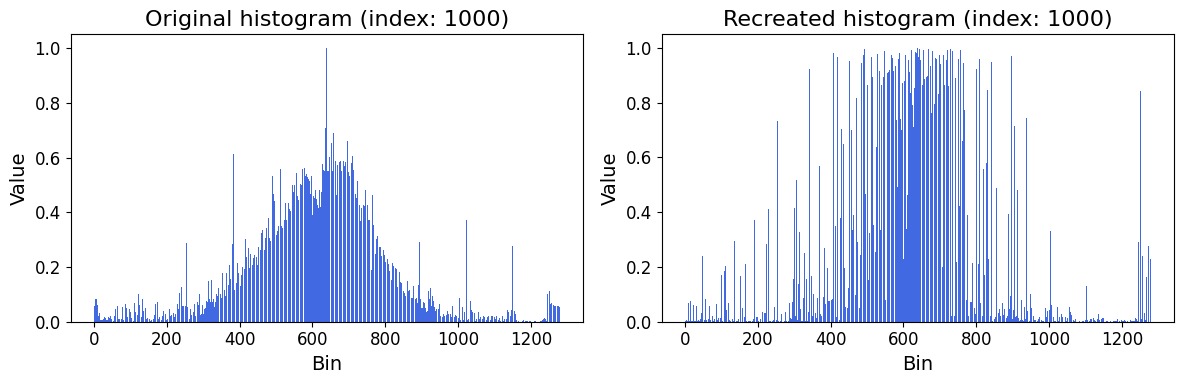

In [138]:
idx = 1000

ae_conv.eval()

pred = ae_conv(torch.tensor(full_dataset[idx].reshape(1, 1, full_dataset[idx].shape[-1]))).detach()

criterion = wasserstein_1d_loss

loss = criterion(pred, torch.tensor(full_dataset[idx]))
pred = pred.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), full_dataset[idx].squeeze(), zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")
plt.tight_layout()
print(loss)
plt.show()

In [135]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-3:])

highest scores [8, 15, 188, 214, 263, 268, 533, 546, 808, 1166]
lowest scores [1391, 173, 1416]


In [136]:
from anomaly_detection.config.paths import CHECKPOINT_DIR

save_model = False

if save_model:
    torch.save({
        "model_state_dict": ae_conv.state_dict(),
        "config": {
            "input_dim": 96,
            "latent_dim": 14,
            "num_latent_space_embeddings" : 32
        }
    }, f"{CHECKPOINT_DIR}/conv_autoenc_v3.pth")